In [1]:
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#cargar dataset final para análisis
df_bcn = pd.read_csv('data/dataset_final.csv', sep=',', engine='python')

In [3]:
# ============================================================
# LIMPIEZA DE COLUMNAS
# ============================================================

# Eliminar columnas innecesarias
cols_drop = [
    'system:index_x', 'system:index_y',
    '.geo_x', '.geo_y',
    'occurrence_x', 'occurrence_y',
    'latitude_y', 'longitude_y',
    'month_y', 'year_y'
]

df_bcn = df_bcn.drop(columns=[c for c in cols_drop if c in df_bcn.columns])

# Renombrar columnas con sufijos
df_bcn = df_bcn.rename(columns={
    'latitude_x':  'latitude',
    'longitude_x': 'longitude',
    'month_x':     'month',
    'year_x':      'year'
})

# Fecha a datetime
df_bcn['fecha'] = pd.to_datetime(df_bcn['fecha'])

# Añadir dayofyear
df_bcn['dayofyear'] = df_bcn['fecha'].dt.dayofyear

# Anomalías térmicas respecto a media mensual
df_bcn['lst_day_c_anomaly'] = (
    df_bcn['lst_day_c']
    - df_bcn.groupby('month')['lst_day_c'].transform('mean')
)

df_bcn['lst_night_c_anomaly'] = (
    df_bcn['lst_night_c']
    - df_bcn.groupby('month')['lst_night_c'].transform('mean')
)

# Ciudad
df_bcn['ciudad'] = 'barcelona'

# ============================================================
# VALIDACIÓN
# ============================================================
print(f'Shape: {df_bcn.shape}')
print(f'Columnas: {df_bcn.columns.tolist()}')
print(f'\nNulos:')
print(df_bcn.isna().mean()[df_bcn.isna().mean() > 0])

df_bcn.to_csv('data/barcelona_clean_dataset.csv', index=False)

Shape: (69683, 26)
Columnas: ['blue', 'bsi', 'fecha', 'green', 'latitude', 'longitude', 'mndwi', 'month', 'nbr', 'ndbi', 'ndmi', 'ndvi', 'ndwi', 'nir', 'point_id', 'red', 'savi', 'swir1', 'swir2', 'year', 'lst_day_c', 'lst_night_c', 'dayofyear', 'lst_day_c_anomaly', 'lst_night_c_anomaly', 'ciudad']

Nulos:
Series([], dtype: float64)


In [ ]:
#Agregar categoría de estación según el mes
def get_season(month):
    if month in [12, 1, 2]:
        return 'invierno'
    elif month in [3, 4, 5]:
        return 'primavera'
    elif month in [6, 7, 8]:
        return 'verano'
    else:
        return 'otoño'

df_bcn['estacion'] = df_bcn['month'].apply(get_season)

print(df_bcn['estacion'].value_counts())

estacion
invierno     17946
verano       17946
primavera    17034
otoño        16757
Name: count, dtype: int64


In [ ]:
# Agregar categoría de amplitud térmica (diferencia entre temperatura diurna y nocturna)
df_bcn['amplitud_termica'] = df_bcn['lst_day_c'] - df_bcn['lst_night_c']

count    69683.000000
mean         9.070026
std          3.690055
min          0.125000
25%          6.070000
50%          9.016667
75%         11.860000
max         20.410000
Name: amplitud_termica, dtype: float64


In [30]:
# Creamos variable objetivo de Riesgo de Isla de Calor (UHI) con 3 categorías: bajo, medio, alto para lst_day_c_anomaly y lst_night_c_anomaly. Imprime los umbrales de cada categoría para ambas variables.
df_bcn['UHI_day'] = pd.qcut(df_bcn['lst_day_c_anomaly'], q=3, labels=['bajo', 'medio', 'alto'])
df_bcn['UHI_night'] = pd.qcut(df_bcn['lst_night_c_anomaly'], q=3, labels=['bajo', 'medio', 'alto'])
print('Umbrales para lst_day_c_anomaly:')
print(df_bcn['lst_day_c_anomaly'].quantile([0.33, 0.66]))
print('\nUmbrales para lst_night_c_anomaly:')

Umbrales para lst_day_c_anomaly:
0.33   -0.956963
0.66    1.211027
Name: lst_day_c_anomaly, dtype: float64

Umbrales para lst_night_c_anomaly:


In [28]:
df_bcn.head()

,blue,bsi,fecha,green,latitude,longitude,mndwi,month,nbr,ndbi,...,lst_day_c,lst_night_c,dayofyear,lst_day_c_anomaly,lst_night_c_anomaly,ciudad,estacion,amplitud_termica,UHI_day,UHI_night
0,0.01515,-0.312553,2020-10-01,0.03050,41.438161,2.099767,-0.542042,10.0,0.674365,-0.358526,...,18.125,10.965,275,-3.561655,-3.955397,barcelona,otoño,7.160,bajo,bajo
1,0.13450,0.106304,2020-10-01,0.17700,41.455948,2.191665,-0.317261,10.0,0.018942,0.069360,...,20.825,12.565,275,-0.861655,-2.355397,barcelona,otoño,8.260,medio,bajo
2,0.09050,0.061652,2020-10-01,0.11915,41.376447,2.102462,-0.350239,10.0,0.054307,0.005074,...,21.685,12.930,275,-0.001655,-1.990397,barcelona,otoño,8.755,medio,bajo
3,0.07690,0.084935,2020-10-01,0.08650,41.396659,2.139652,-0.121158,10.0,-0.036384,0.116056,...,21.835,14.425,275,0.148345,-0.495397,barcelona,otoño,7.410,medio,medio
4,0.06340,0.061221,2020-10-01,0.09945,41.368093,2.043173,-0.362908,10.0,0.189122,-0.056646,...,23.155,11.635,275,1.468345,-3.285397,barcelona,otoño,11.520,alto,bajo


In [29]:
df_bcn.info()

<class 'pandas.DataFrame'>
RangeIndex: 69683 entries, 0 to 69682
Data columns (total 30 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   blue                 69683 non-null  float64       
 1   bsi                  69683 non-null  float64       
 2   fecha                69683 non-null  datetime64[us]
 3   green                69683 non-null  float64       
 4   latitude             69683 non-null  float64       
 5   longitude            69683 non-null  float64       
 6   mndwi                69683 non-null  float64       
 7   month                69683 non-null  float64       
 8   nbr                  69683 non-null  float64       
 9   ndbi                 69683 non-null  float64       
 10  ndmi                 69683 non-null  float64       
 11  ndvi                 69683 non-null  float64       
 12  ndwi                 69683 non-null  float64       
 13  nir                  69683 non-null  float

In [26]:
df_bcn.shape

(69683, 28)

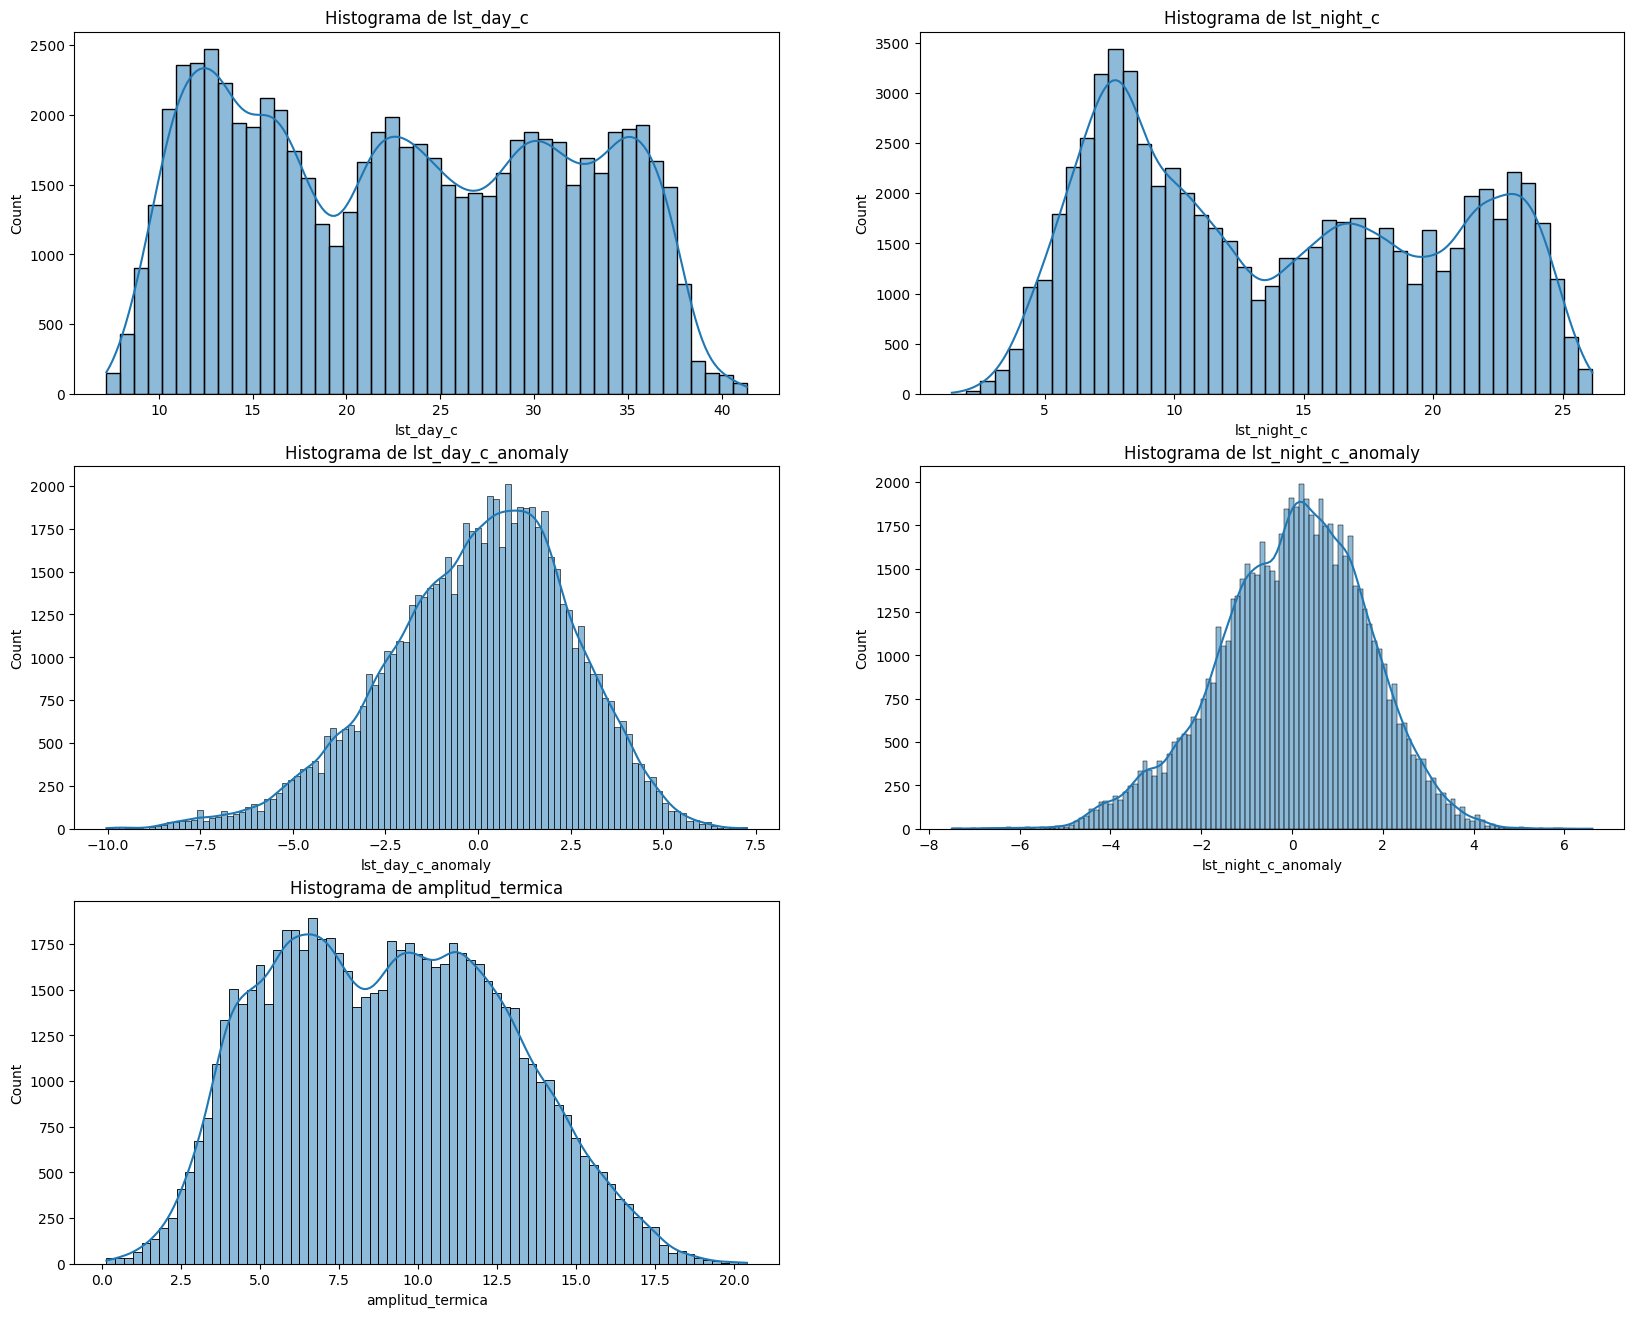

In [33]:
#Matriz de frecuencias de todas las variables numéricas
plt.figure(figsize=(20, 16))
cols_hist = ['lst_day_c', 'lst_night_c', 'lst_day_c_anomaly', 'lst_night_c_anomaly', 'amplitud_termica']
for i, col in enumerate(cols_hist):
    plt.subplot(3, 2, i+1)
    sns.histplot(df_bcn[col], kde=True)
    plt.title(f'Histograma de {col}')


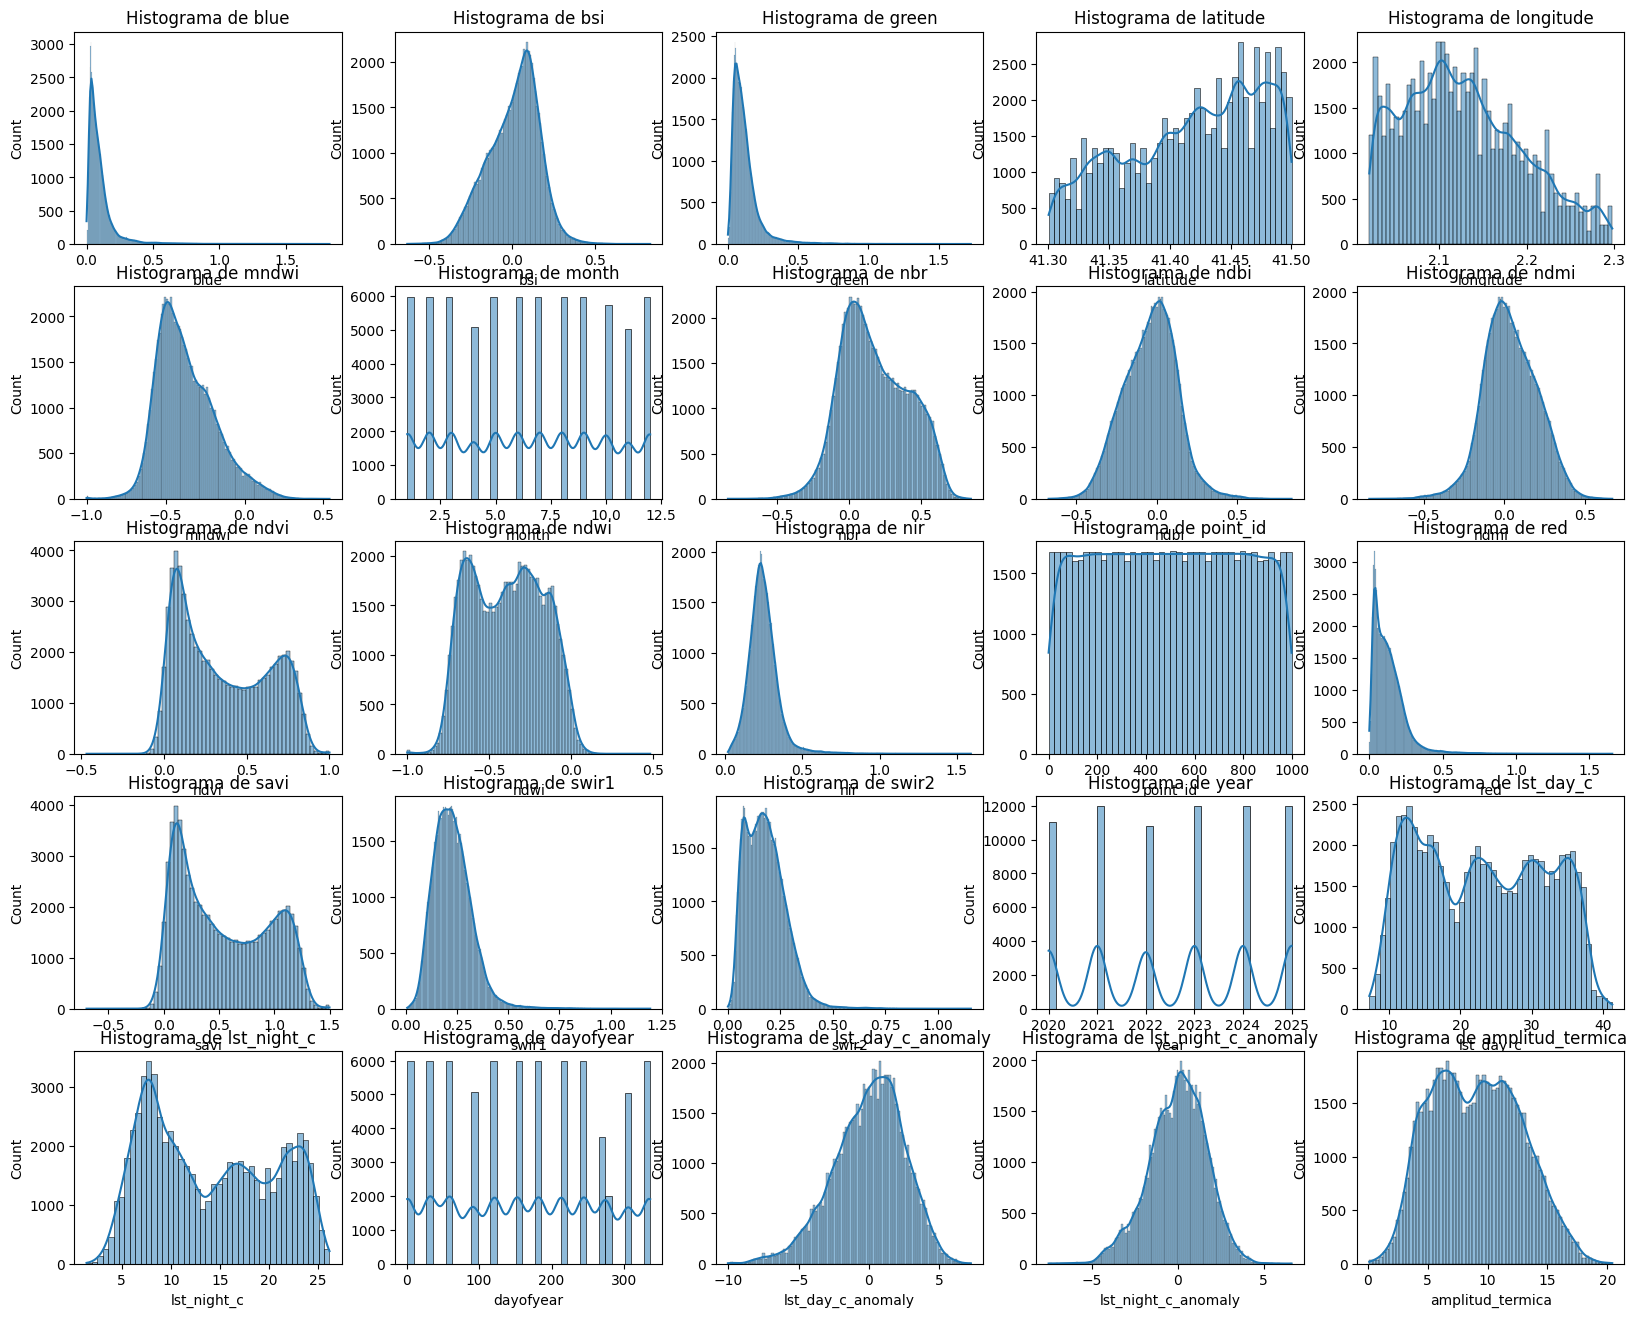

In [39]:
#Matriz de frecuencias de todas las variables de indices
plt.figure(figsize=(20, 16))
cols_hist = ['blue', 'bsi', 'green', 'latitude', 'longitude', 'mndwi', 'month', 'nbr', 'ndbi', 'ndmi', 'ndvi', 'ndwi', 'nir', 'point_id', 'red', 'savi', 'swir1', 'swir2', 'year', 'lst_day_c', 'lst_night_c', 'dayofyear', 'lst_day_c_anomaly', 'lst_night_c_anomaly', 'amplitud_termica']
for i, col in enumerate(cols_hist):
    plt.subplot(5, 5, i+1)
    sns.histplot(df_bcn[col], kde=True)
    plt.title(f'Histograma de {col}')

<Axes: >

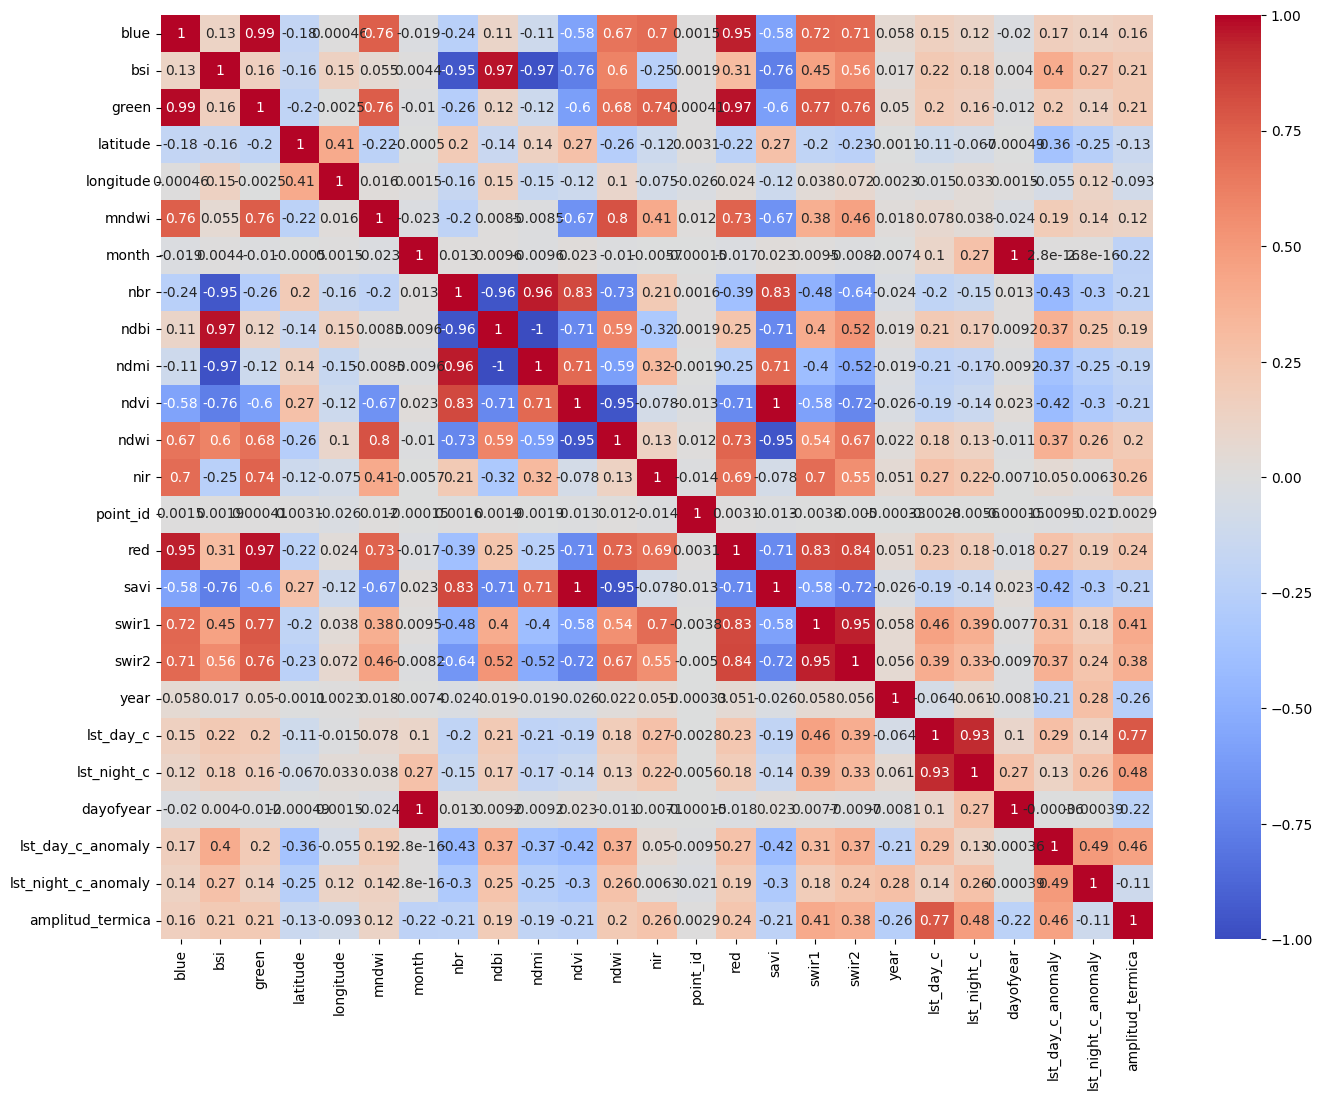

In [40]:
#matriz de correlación entre todos los indicadores
plt.figure(figsize=(16, 12))

cols_corr = ['blue', 'bsi', 'green', 'latitude', 'longitude', 'mndwi', 'month', 'nbr', 'ndbi', 'ndmi', 'ndvi', 'ndwi', 'nir', 'point_id', 'red', 'savi', 'swir1', 'swir2', 'year', 'lst_day_c', 'lst_night_c', 'dayofyear', 'lst_day_c_anomaly', 'lst_night_c_anomaly', 'amplitud_termica']
corr_matrix = df_bcn[cols_corr].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0)

In [41]:
#listado de máximo y mínimo de cada variable
for col in cols_corr:
    print(f'{col}: min={df_bcn[col].min()}, max={df_bcn[col].max()}')

blue: min=0.0, max=1.828
bsi: min=-0.6295015412375009, max=0.828307392996109
green: min=0.0, max=1.7288
latitude: min=41.30044942927287, max=41.50014491693264
longitude: min=2.0199966636353395, max=2.2978455810134903
mndwi: min=-1.0, max=0.5380308
month: min=1.0, max=12.0
nbr: min=-0.8434707, max=0.84782606
ndbi: min=-0.671422, max=0.8371513
ndmi: min=-0.8371513, max=0.671422
ndvi: min=-0.46530902, max=1.0
ndwi: min=-1.0, max=0.48056132
nir: min=0.0161, max=1.5928
point_id: min=0.0, max=999.0
red: min=0.0, max=1.6568
savi: min=-0.6979222163026105, max=1.4984833164812943
swir1: min=0.0074, max=1.1928
swir2: min=0.0014, max=1.1578
year: min=2020, max=2025
lst_day_c: min=7.205000000000041, max=41.34500000000003
lst_night_c: min=1.4233333333333462, max=26.15000000000004
dayofyear: min=1, max=336
lst_day_c_anomaly: min=-10.03236949375409, max=7.255902429510758
lst_night_c_anomaly: min=-7.493673241948082, max=6.615014766521778
amplitud_termica: min=0.125, max=20.410000000000025


In [ ]:
#Anaís, creamos un listado de pares de variables numéricas con alta correlación (> 0.75) 
#para identificar posibles redundancias o relaciones fuertes entre indicadores. 
#Queda pendiente decidir cuales eliminamos


# ============================================================
# CORRELACIÓN ENTRE VARIABLES NUMÉRICAS
# ============================================================

# Seleccionar solo columnas numéricas
numeric_cols = df_bcn.select_dtypes(include='number').columns.tolist()

# Calcular matriz de correlación
corr_matrix = df_bcn[numeric_cols].corr().abs()

# Extraer pares con correlación > 0.75 (sin duplicados ni diagonal)
upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

pares_alta_corr = (
    upper.stack()
    .reset_index()
    .rename(columns={'level_0': 'var1', 'level_1': 'var2', 0: 'correlacion'})
    .query('correlacion > 0.75')
    .sort_values('correlacion', ascending=False)
    .reset_index(drop=True)
)

print(f'Pares con correlación > 0.75: {len(pares_alta_corr)}')
print(pares_alta_corr.to_string())

Pares con correlación > 0.75: 27
         var1              var2  correlacion
0        ndbi              ndmi     1.000000
1        ndvi              savi     1.000000
2       month         dayofyear     0.999974
3        blue             green     0.988280
4       green               red     0.974108
5         bsi              ndmi     0.969877
6         bsi              ndbi     0.969877
7         nbr              ndmi     0.955611
8         nbr              ndbi     0.955611
9        ndwi              savi     0.954406
10       ndvi              ndwi     0.954402
11        bsi               nbr     0.951002
12      swir1             swir2     0.950230
13       blue               red     0.949495
14  lst_day_c       lst_night_c     0.928911
15        red             swir2     0.838312
16        red             swir1     0.833202
17        nbr              savi     0.833080
18        nbr              ndvi     0.833061
19      mndwi              ndwi     0.803512
20  lst_day_c  amplitu

| Variable a eliminar | Por qué |
|---|---|
| `ndmi` | Correlación 1.0 con `ndbi` — son inversos exactos: `ndmi = (B8-B11)/(B8+B11)` y `ndbi = (B11-B8)/(B11+B8)` |
| `savi` | Correlación 1.0 con `ndvi` — solo difiere en un factor constante (1.5) y el +0.5, sin aporte nuevo en Barcelona |
| `dayofyear` | Correlación 0.999 con `month` — redundante, `month` es más interpretable |
| `ndwi` | Correlación 0.95 con `ndvi` y 0.80 con `mndwi` — aporta menos que `mndwi` que usa SWIR en lugar de NIR |
| `green` | Correlación >0.97 con `blue` y `red` — las tres bandas del visible están muy correlacionadas, `green` es la más redundante |
| `swir2` | Correlación 0.95 con `swir1` y 0.83 con `red` — `swir1` ya está presente y es más usado en índices |
| `nbr` | Correlación >0.95 con `ndbi` y `ndmi`, y 0.83 con `ndvi` — no añade información independiente |

In [ ]:
#Pensar si vamos a dejar variables de fecha: day of year, month, estacion
cols_eliminar = ['ndmi', 'savi', 'month', 'ndwi', 'green', 'swir2', 'nbr', 'red','blue']

df_bcn = df_bcn.drop(columns=cols_eliminar)

print(f'Shape tras eliminación: {df_bcn.shape}')
print(f'Columnas restantes: {df_bcn.columns.tolist()}')

Shape tras eliminación: (69683, 21)
Columnas restantes: ['bsi', 'fecha', 'latitude', 'longitude', 'mndwi', 'ndbi', 'ndvi', 'nir', 'point_id', 'swir1', 'year', 'lst_day_c', 'lst_night_c', 'dayofyear', 'lst_day_c_anomaly', 'lst_night_c_anomaly', 'ciudad', 'estacion', 'amplitud_termica', 'UHI_day', 'UHI_night']
